Cubo Gelatinoso
===============

**Autor:** Leticia Campos da Silva

## Introdução


Este projeto tem como objetivo estudar o desempenho do algoritmo de $k$ vizinhos mais próximos ($k$-NN), testando diferentes combinações de hiperparâmetros e avaliando os resultados com uma métrica de desempenho apropriada.

Dado um livro que esteve entre os mais vendidos da Amazon, o objetivo é prever se ele é um livro de **ficção** ou **não-ficção** (`Genre`). Esse é um exemplo de classificação binária: o modelo recebe as características do livro e decide entre duas classes possíveis.

**Conjunto de dados:** *Amazon Top 50 Bestselling Books 2009-2019* , 550 livros que estiveram entre os mais vendidos da Amazon nesse período.

-   Atributos: `Author` (categórico), `User Rating`, `Reviews`, `Price`, `Year`
-   Target: `Genre` (`Fiction` / `Non Fiction`)

## Carregamento dos dados

In [1]:
import pandas as pd 

url_dataset = "https://raw.githubusercontent.com/dphi-official/Datasets/master/Amazon%20Top%2050%20Bestselling%20Books%202009%20-%202019.csv"

df = pd.read_csv(url_dataset)
df

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
...,...,...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction


## Tratamento dos dados

Observando as colunas do Dataframe, percebe-se que `Name` é praticamente único de cada livro, repete apenas se o livro foi bestseller em mais de um ano. Nesse caso, como não há um padrão de repetição que possa ser generalizado, esse coluna será descartada. 

In [2]:
df = df.drop(columns=["Name"])

Em seguida, a coluna `Author` é o atributo categórico do projeto, portanto vale analisá-la. A célula a seguir mostra que das 550 linhas do DataFrame apenas 248 são únicos, o que implica em repetição

In [3]:
print("Linhas totais:", len(df))
print("Autores únicos:", df["Author"].nunique())

Linhas totais: 550
Autores únicos: 248


Nesse caso usar `OneHotEnconder` criaria quase uma coluna por exemplo, o que atrapalha o $k$-NN (a distância entre os pontos passa a ser dominada por atributos dispersos). Em vez disso, usar uma codificação por frequência melhora o resultado: cada autor é substituído pelo número de vezes que aparece no conjunto de dados.

In [4]:
contagem_autores = df["Author"].value_counts()
df["Author_Freq"] = df["Author"].map(contagem_autores)
df = df.drop(columns=["Author"])
df

,User Rating,Reviews,Price,Year,Genre,Author_Freq
0,4.7,17350,8,2016,Non Fiction,1
1,4.6,2052,22,2011,Fiction,4
2,4.7,18979,15,2018,Non Fiction,1
3,4.7,21424,6,2017,Fiction,1
4,4.8,7665,12,2019,Non Fiction,1
...,...,...,...,...,...,...
545,4.9,9413,8,2019,Fiction,12
546,4.7,14331,8,2016,Non Fiction,4
547,4.7,14331,8,2017,Non Fiction,4
548,4.7,14331,8,2018,Non Fiction,4


A seguir, os atributos e o target são definidos e as linhas com células vazias são removidas.

In [5]:
ATRIBUTOS = ["User Rating", "Reviews", "Price", "Year", "Author_Freq"]
TARGET = ["Genre"]

df = df.reindex(ATRIBUTOS + TARGET, axis=1)
df = df.dropna()

df

,User Rating,Reviews,Price,Year,Author_Freq,Genre
0,4.7,17350,8,2016,1,Non Fiction
1,4.6,2052,22,2011,4,Fiction
2,4.7,18979,15,2018,1,Non Fiction
3,4.7,21424,6,2017,1,Fiction
4,4.8,7665,12,2019,1,Non Fiction
...,...,...,...,...,...,...
545,4.9,9413,8,2019,12,Fiction
546,4.7,14331,8,2016,4,Non Fiction
547,4.7,14331,8,2017,4,Non Fiction
548,4.7,14331,8,2018,4,Non Fiction


Antes de seguir, é valido checar o balanceamento do target escolhido.

In [6]:
df["Genre"].value_counts(normalize=True)

Genre
Non Fiction    0.563636
Fiction        0.436364
Name: proportion, dtype: float64

Observa-se que o target `Genre` está razoavelmente balanceado entre as duas classes (cerca de 56% `Non Fiction` e 44% `Fiction`). Em sequência, têm-se uma visualização gráfica dessa distribuição. 

<Axes: title={'center': 'Distribuição do target (Genre)'}, xlabel='Genre'>

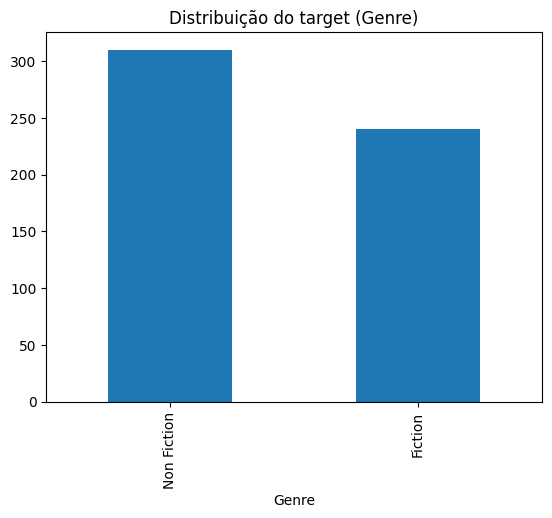

In [7]:
df["Genre"].value_counts().plot(kind="bar", title="Distribuição do target (Genre)")

## Divisão em treino e teste

Antes de treinar o modelo, separam-se os dados em dois conjuntos: treino, que o modelo vai usar para aprender, e teste, que fica de fora do treino e serve só para avaliar o desempenho final. Isso simula como o modelo se comportaria diante de livros que ele nunca viu. A seguir, 20% dos dados são usados para teste, e fixamos uma semente aleatória (SEMENTE_ALEATORIA) para que a divisão seja sempre a mesma toda vez que o notebook rodar.

In [8]:
from sklearn.model_selection import train_test_split

TAMANHO_TESTE = 0.2
SEMENTE_ALEATORIA = 146

indices = df.index
indices_treino, indices_teste = train_test_split(
    indices, test_size=TAMANHO_TESTE, random_state=SEMENTE_ALEATORIA
)

df_treino = df.loc[indices_treino]
df_teste = df.loc[indices_teste]

X_treino = df_treino.reindex(ATRIBUTOS, axis=1).values
y_treino = df_treino.reindex(TARGET, axis=1).values.ravel()

X_teste = df_teste.reindex(ATRIBUTOS, axis=1).values
y_teste = df_teste.reindex(TARGET, axis=1).values.ravel()

ordem_labels = df["Genre"].unique().tolist()
ordem_labels

['Non Fiction', 'Fiction']

## Modelo baseline

Antes de inverstir em hiperparâmetros, vale ter um modelo baseline simples de comparação: um `DummyClassifier`, que prevê a classe mais frequente.

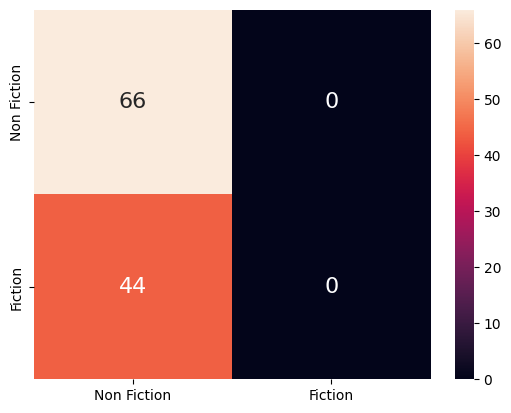

In [9]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

modelo_baseline = DummyClassifier()
modelo_baseline.fit(X_treino, y_treino)

y_verdadeiro = y_teste
y_previsao = modelo_baseline.predict(X_teste)

matriz_conf = confusion_matrix(y_verdadeiro, y_previsao, labels=ordem_labels)
df_conf = pd.DataFrame(matriz_conf, ordem_labels, ordem_labels)

sns.heatmap(df_conf, annot=True, annot_kws={"size": 16});

A matriz de confusão mostra, para cada classe real, o que o modelo previu: a diagonal principal são os acertos, e fora dela estão os erros, já indicando em qual direção o modelo mais confunde as classes.

In [10]:
acuracia_baseline = accuracy_score(y_verdadeiro, y_previsao)

print(f"Acurácia do baseline = {(acuracia_baseline*100):.2f}%")

Acurácia do baseline = 60.00%


 A acurácia resume esse resultado em um único número, a proporção de previsões corretas sobre o total, o que facilita comparar diferentes modelos e hiperparâmetros entre si.

## Normalização dos atributos

O $k$-NN mede distância entre exemplos, então atributos em escalas muito diferentes (como `Review` na casa dos milhares e `User rating` entre 0 e 5) dominariam a distância se não fossem normalizados. O normalizador é ajustado com o conjunto de treino aplicado tanto no treino quanto no teste.

In [11]:
from sklearn.preprocessing import StandardScaler

normalizador = StandardScaler()
normalizador.fit(X_treino)

X_treino_norm = normalizador.transform(X_treino)
X_teste_norm = normalizador.transform(X_teste)

## Testando diferentes conjuntos de hiperparâmetros 

Agora, variam-se dois hiperparâmetros do $k$-NN:

- `n_neighbord` (número de vizinhos): 3, 5, 7, 9, 11
- `p` (tipo de distância): `p=1` é a distância Manhattan, `p=2` é a distância Euclidiana (padrão), `p=3` é uma representação da fórmula de Minkowski elevando cada diferença ao cubo e tirando a raiz cúbica no final.
  
Isso dá $5 \times 3 = 15$ conjuntos de hierparâmetros diferentes. Para cada combinação, treina-se no conjunto de treino e avalia-se a acurácia no conjunto de teste.

In [12]:
from sklearn.neighbors import KNeighborsClassifier

N_VIZINHOS_LISTA = [3, 5, 7, 9, 11]
P_LISTA = [1, 2, 3]

resultados = []

for n_vizinhos in N_VIZINHOS_LISTA:
    for p in P_LISTA:
        modelo_knn = KNeighborsClassifier(n_neighbors=n_vizinhos, p=p)
        modelo_knn.fit(X_treino_norm, y_treino)

        y_previsao = modelo_knn.predict(X_teste_norm)
        acuracia = accuracy_score(y_teste, y_previsao)

        resultados.append({"n_neighbors": n_vizinhos, "p": p, "acuracia_teste": acuracia})

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values("acuracia_teste", ascending=False)
df_resultados = df_resultados.reset_index(drop=True)
df_resultados

,n_neighbors,p,acuracia_teste
0,3,1,0.827273
1,5,1,0.800000
2,3,2,0.763636
3,3,3,0.763636
4,9,1,0.754545
5,11,1,0.754545
6,7,1,0.745455
7,7,2,0.736364
8,7,3,0.727273
9,9,2,0.718182


A partir da análise acima, pode-se determinar a melhor combinação a ser usada no modelo.

In [13]:
melhores_hiperparametros = df_resultados.iloc[0]

print("Melhores hiperparâmetros encontrados:")
print(melhores_hiperparametros)

Melhores hiperparâmetros encontrados:
n_neighbors       3.000000
p                 1.000000
acuracia_teste    0.827273
Name: 0, dtype: float64


## Modelo Final

Agora, o $k$-NN é treinado com os melhores hiperparâmetros encontrados e olha a matriz de confusão do resultado. 

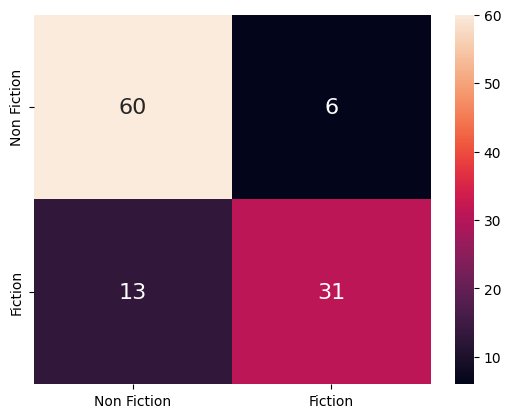

In [14]:
modelo_knn_final = KNeighborsClassifier(
    n_neighbors=int(melhores_hiperparametros["n_neighbors"]),
    p=int(melhores_hiperparametros["p"]),
)
modelo_knn_final.fit(X_treino_norm, y_treino)

y_verdadeiro = y_teste
y_previsao = modelo_knn_final.predict(X_teste_norm)

matriz_conf = confusion_matrix(y_verdadeiro, y_previsao, labels=ordem_labels)
df_conf = pd.DataFrame(matriz_conf, ordem_labels, ordem_labels)

sns.heatmap(df_conf, annot=True, annot_kws={"size": 16});

In [15]:
acuracia_final = accuracy_score(y_verdadeiro, y_previsao)

print(f"Acurácia do baseline = {(acuracia_baseline*100):.2f}%")
print(f"Acurácia do k-NN final = {(acuracia_final*100):.2f}%")

Acurácia do baseline = 60.00%
Acurácia do k-NN final = 82.73%


A matriz de confusão revela uma assimetria que a acurácia geral (82,73%) não deixa clara:

|                    | Previsto: Non Fiction | Previsto: Fiction |
|--------------------|:---:|:---:|
| **Real: Non Fiction** (65) | 60 | 6 |
| **Real: Fiction** (45)     | 13 | 31 |

Olhando linha por linha, o modelo acerta 92,3% dos livros que realmente são `Non Fiction`, mas apenas 68,9% dos que são `Fiction`. Ou seja, o modelo é bem mais confiável para reconhecer não-ficção do que ficção.

Essa assimetria provavelmente vem do próprio desbalanceamento leve do target (56% `Non Fiction` contra 44% `Fiction`). Como o k-NN decide a classe de um exemplo com base na maioria dos seus vizinhos mais próximos, e há mais exemplos de `Non Fiction` disponíveis no treino, um livro que fique numa região "ambígua" do espaço de atributos tem mais chance de ter a maioria dos vizinhos rotulados como `Non Fiction`, puxando o modelo para errar mais nessa direção.

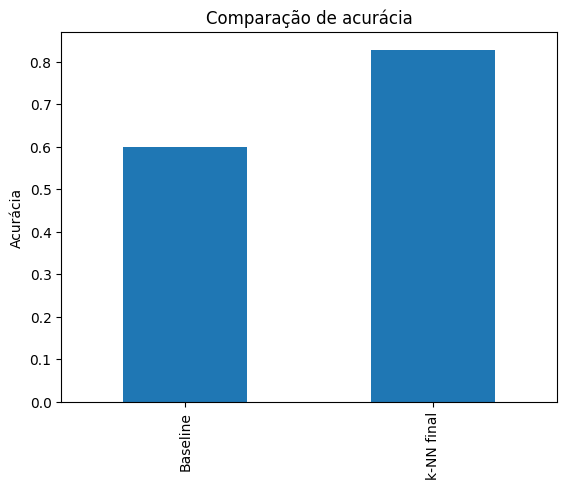

In [16]:
import matplotlib.pyplot as plt
comparacao = pd.Series(
    {"Baseline": acuracia_baseline, "k-NN final": acuracia_final}
)
comparacao.plot(kind="bar", title="Comparação de acurácia")
plt.ylabel("Acurácia")
plt.show()

O gráfico de comparação deixa visualmente clara a diferença entre os dois modelos: o `k-NN` final atinge 82,73% de acurácia, contra 60,00% do baseline, um ganho de quase 23 pontos percentuais. Essa diferença é uma evidência direta de que o modelo está de fato aprendendo um padrão a partir dos atributos disponíveis, e não apenas repetindo a proporção das classes do target, que é exatamente o que o `DummyClassifier` faz.

Vale notar que os 60% do baseline já são um número relativamente alto para uma previsão "chutada", reflexo direto do target ser razoavelmente balanceado. Se o desbalanceamento fosse mais forte, o baseline teria uma barra ainda mais alta no gráfico, o que tornaria a comparação com o modelo final menos informativa: um ganho de poucos pontos percentuais sobre um baseline de 90%, por exemplo, seria bem menos impressionante do que os quase 23 pontos de ganho observados aqui sobre um baseline de 60%.

Esse tipo de comparação gráfica reforça por que usar um baseline simples é uma boa prática antes de avaliar qualquer modelo mais sofisticado: sem ele, o número de 82,73% de acurácia poderia parecer bom ou ruim dependendo da expectativa, mas colocado lado a lado com o baseline ele ganha um referencial concreto de comparação.

## Conclusões e principais aprendizados

O modelo de $k$-NN com os melhores hiperparâmetros encontrados (`n_neighbors=3`, `p=1`, distância Manhattan) atingiu 82,73% de acurácia no teste, superando com folga o baseline de 60,00% (`DummyClassifier`, que sempre prevê a classe majoritária). Isso mostra que os atributos escolhidos carregam alguma informação real sobre o gênero do livro, e não que o modelo está apenas repetindo a proporção das classes.

A matriz de confusão do modelo final revelou uma assimetria importante: o modelo reconhece melhor livros de `Non Fiction` do que de `Fiction`, provavelmente por conta do leve desbalanceamento do target. Esse tipo de detalhe fica escondido quando se olha só a acurácia geral, reforçando a importância de examinar a matriz de confusão além do número único de desempenho.

Ainda assim, o desempenho é moderado, não excelente, o que faz sentido dado que os atributos disponíveis (nota do usuário, número de avaliações, preço, ano e popularidade do autor) descrevem principalmente o desempenho comercial do livro, não o seu conteúdo.

Entre os hiperparâmetros testados, valores menores de `p` na distância de Minkowski tiveram desempenho melhor: `p=1` (Manhattan) superou `p=2` (Euclidiana), que por sua vez superou `p=3`, tanto na melhor combinação encontrada quanto na média de acurácia entre todos os valores de `n_neighbors` testados. Isso é um indício de que, mesmo com apenas 5 atributos, distâncias que penalizam menos diferenças extremas em um único atributo (como `Author_Freq`, concentrado perto de 1 para a maioria dos autores mas alto para poucos "recordistas") generalizam melhor nesse conjunto de dados.

Por fim, o tratamento do atributo categórico `Author` (com 248 valores únicos em 550 linhas) mostrou como a cardinalidade alta de uma variável categórica pode inviabilizar técnicas simples como o one-hot encoding, tornando a codificação por frequência uma alternativa mais adequada nesse contexto.

## Descrição do uso de IA nesse trabalho

O assistente de IA Claude (Anthropic) foi utilizado como ferramenta de apoio ao longo do desenvolvimento deste trabalho, tanto na escrita e explicação do código quanto para entendimento dos notebooks de aula. A seguir, detalho os principais momentos de interação:

**Escolha do conjunto de dados:** Pedi sugestões de datasets do Kaggle que atendessem aos critérios da atividade. 

**Estrutura do código:** Enviei os notebooks de aula da disciplina e pedi explicações de conceitos dos quais fiquei em dúvida.

**Explicação do código:** Ao longo do desenvolvimento, pedi explicações do que alguns trechos de código faziam para garantir que eu entendia e conseguia justificar cada decisão tomada no notebook.

**Identificação e correção de um erro:** Durante os testes, percebi uma inconsistência entre o resultado da busca de hiperparâmetros e o resultado do modelo final e pedi ajuda para investigar a causa. 

**Redação de textos:** Utilizei a IA para revisar trechos textuais do notebook.


## Refêrencias

SOOTERSAALU. **Amazon Top 50 Bestselling Books 2009-2019**. Kaggle, 2020. Disponível em: https://www.kaggle.com/datasets/sootersaalu/amazon-top-50-bestselling-books-2009-2019. Acesso em: 10 set. 2026.

CASSAR, Daniel R. **Tratamento de dados com pandas: ATP-203 1.1**, Aprendizado de Máquina. [Ilum Escola de Ciência], [2026]. 1 notebook Jupyter. Notas de aula.

CASSAR, Daniel R. **Aprendizado de máquina, k-NN e métricas: ATP-203 2.1**, Aprendizado de Máquina. [Ilum Escola de Ciência], [2026]. 1 notebook Jupyter. Notas de aula.

CASSAR, Daniel R. **Divisão de dados em treino e teste: ATP-203 2.2**, Aprendizado de Máquina. [Ilum Escola de Ciência], [2026]. 1 notebook Jupyter. Notas de aula.

CASSAR, Daniel R. **Modelo linear e baseline: ATP-203 3.0**, Aprendizado de Máquina. [Ilum Escola de Ciência], [2026]. 1 notebook Jupyter. Notas de aula.

CASSAR, Daniel R. **Classificação binária: ATP-203 5.0**, Aprendizado de Máquina. [Ilum Escola de Ciência], [2026]. 1 notebook Jupyter. Notas de aula.

SCIKIT-LEARN. **DistanceMetric — scikit-learn 1.9.1 documentation**. [S. l.]: scikit-learn developers, [20--]. Disponível em: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.DistanceMetric.html. Acesso em: 13 set. 2026.